# HW 3: Deep Learning For Dynamical Systems

## In this problem, you should use PyTorch to train a neural network (NN). onsider the Lorenz system (code for solving this ODE was provided during our dynamical systems lectures). Use the default parameters in our code except as noted below. You can use this code to generate training data as needed. Our goal is to have a NN that takes the solution at an arbitrary time t and predicts the next time-step t + ∆t as output. Use fully connected neural networks.

## (a) Train a NN to advance the solution from t to t+∆t for ρ = 10,28 and 40 (recall ρ was one of the Lorenz parameters). Generate training data in a certain range 0 < t < T and by using various initial conditions. Make sure you split your training data into training and validation. After training, now see how well your NN works for future state prediction for ρ =17 and ρ=35. Attempt to predict within 0 < t < T. Deliverables: Your training loss plot (loss vs. epoch), your validation loss plot (loss vs. epoch), your neural network’s prediction on the unseen ρ values given an arbitrary initial condition.

In [1]:
# import libraries
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Constants for randomization
torch.manual_seed(42)
np.random.seed(42)

# Physical constants (fixed, as given in the course code)
dt    = 0.01
T     = 50
beta  = 8/3
sigma = 10

# define the Lorenz system derivatives
def lorenz_deriv(state, t, sigma, beta, rho):
    x, y, z = state
    return [sigma*(y - x), x*(rho - z) - y, x*y - beta*z]

# Function to generate a single trajectory for a given rho and initial condition
def generate_trajectory(rho, x0):
    """Integrate one Lorenz trajectory, return (N, 3) array."""
    t_span = np.arange(dt, T + dt, dt)   # length 5000 for T=50, dt=0.01
    traj = odeint(lorenz_deriv, x0, t_span,
                  args=(sigma, beta, rho),
                  rtol=10**(-12),
                  atol=10**(-12)*np.ones_like(x0))
    return traj   # shape (5000, 3)

def make_dataset(rho_list, n_ics=10):
    """
    For each rho in rho_list, simulate n_ics trajectories from random ICs.
    
    Each trajectory of length N gives (N-1) input/output pairs:
        input  : [x_t, y_t, z_t, rho]   shape (4,)
        output : [x_{t+dt}, y_{t+dt}, z_{t+dt}]  shape (3,)
    
    Returns X (inputs) and Y (targets) as float32 numpy arrays.
    """
    X_list, Y_list = [], []
    
    for rho in rho_list:
        for _ in range(n_ics):
            # Random initial condition in a reasonable range
            x0 = np.random.uniform(-20, 20, size=3)
            
            traj = generate_trajectory(rho, x0)   # (5000, 3)
            
            # Consecutive pairs: traj[:-1] → traj[1:]
            inputs  = traj[:-1]   # (4999, 3) state at time t
            targets = traj[1:]    # (4999, 3) state at time t+dt
            
            # Append rho as a 4th input feature for every time step
            rho_col = np.full((len(inputs), 1), rho) # (4999, 1)
            inputs  = np.hstack([inputs, rho_col]) # (4999, 4)
            
            X_list.append(inputs)
            Y_list.append(targets)
    
    X = np.vstack(X_list).astype(np.float32) # (total_samples, 4)
    Y = np.vstack(Y_list).astype(np.float32) # (total_samples, 3)
    return X, Y

# Training rho values (as specified in the problem)
rho_train = [10, 28, 40]
X, Y = make_dataset(rho_train, n_ics=10)

print(f"Total samples: {X.shape[0]:,}")   # ~149,970
print(f"Input shape:   {X.shape}")
print(f"Output shape:  {Y.shape}")

class Normalizer:
    """
    Standardizes data to zero mean, unit variance.
    Fit on training data only, then apply to everything.
    """
    def __init__(self):
        self.mean = None
        self.std  = None
    
    def fit(self, data):
        self.mean = data.mean(axis=0)
        self.std  = data.std(axis=0)
        self.std[self.std < 1e-8] = 1.0  # avoid divide-by-zero for constant cols
        return self
    
    def transform(self, data):
        return (data - self.mean) / self.std
    
    def inverse_transform(self, data):
        return data * self.std[:3] + self.mean[:3]  # only for output (3D)

# Fit normalizer on training inputs ONLY (never on val or test)
norm_X = Normalizer().fit(X)
norm_Y = Normalizer().fit(Y)

X_norm = norm_X.transform(X)
Y_norm = norm_Y.transform(Y)

# Rebuild tensors and loaders with normalized data
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
Y_tensor = torch.tensor(Y_norm, dtype=torch.float32)

dataset = TensorDataset(X_tensor, Y_tensor)
n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val   = n_total - n_train
train_set, val_set = random_split(dataset, [n_train, n_val],
                                  generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_set,   batch_size=1024, shuffle=False)

Total samples: 149,970
Input shape:   (149970, 4)
Output shape:  (149970, 3)


Epoch  10 | Train MSE: 0.000932 | Val MSE: 0.000618
Epoch  20 | Train MSE: 0.000417 | Val MSE: 0.000180
Epoch  30 | Train MSE: 0.000265 | Val MSE: 0.000523
Epoch  40 | Train MSE: 0.000022 | Val MSE: 0.000017
Epoch  50 | Train MSE: 0.000011 | Val MSE: 0.000011
Epoch  60 | Train MSE: 0.000009 | Val MSE: 0.000006
Epoch  70 | Train MSE: 0.000004 | Val MSE: 0.000004
Epoch  80 | Train MSE: 0.000004 | Val MSE: 0.000005
Epoch  90 | Train MSE: 0.000002 | Val MSE: 0.000003
Epoch 100 | Train MSE: 0.000002 | Val MSE: 0.000003
Epoch 110 | Train MSE: 0.000002 | Val MSE: 0.000003
Epoch 120 | Train MSE: 0.000002 | Val MSE: 0.000003
Epoch 130 | Train MSE: 0.000001 | Val MSE: 0.000002
Epoch 140 | Train MSE: 0.000001 | Val MSE: 0.000002
Epoch 150 | Train MSE: 0.000001 | Val MSE: 0.000001
Epoch 160 | Train MSE: 0.000001 | Val MSE: 0.000002
Epoch 170 | Train MSE: 0.000001 | Val MSE: 0.000001
Epoch 180 | Train MSE: 0.000001 | Val MSE: 0.000001
Epoch 190 | Train MSE: 0.000001 | Val MSE: 0.000001
Epoch 200 | 

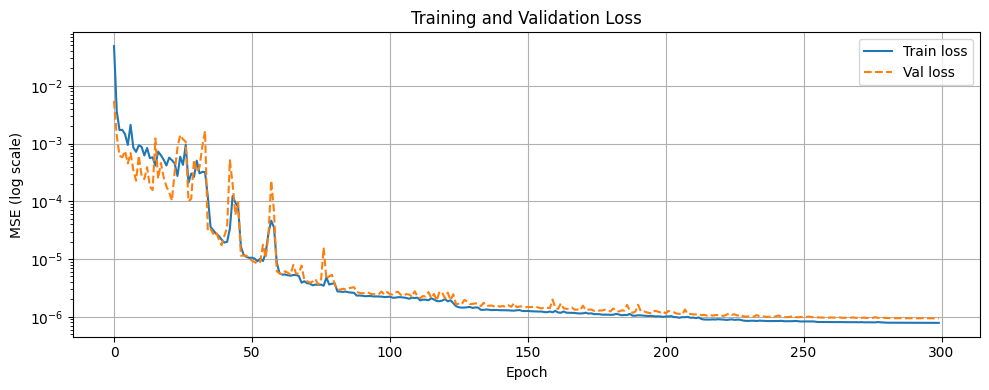

In [2]:
class LorenzNet(nn.Module):
    """
    Fully connected network: (x, y, z, rho) -> (x', y', z')
    
    Architecture: 4 -> [hidden]*n_layers -> 3
    Each hidden layer uses Tanh activation (works well for smooth dynamics).
    """
    def __init__(self, hidden_size=128, n_layers=4):
        super().__init__()
        
        layers = [nn.Linear(4, hidden_size), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers.append(nn.Linear(hidden_size, 3))   # output layer, no activation
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

# Bigger network — more capacity to learn the parametric family
model = LorenzNet(hidden_size=256, n_layers=5)

# Train for longer
n_epochs = 300

# training setup
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)
loss_fn = nn.MSELoss()

train_losses, val_losses = [], []

for epoch in range(1, n_epochs + 1):
    
    # Training
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(xb)
    train_losses.append(running_loss / n_train)
    
    # Validation
    model.eval()
    with torch.no_grad():
        running_val = 0.0
        for xb, yb in val_loader:
            pred = model(xb)
            running_val += loss_fn(pred, yb).item() * len(xb)
    val_losses.append(running_val / n_val)
    
    scheduler.step(val_losses[-1])
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train MSE: {train_losses[-1]:.6f} | Val MSE: {val_losses[-1]:.6f}")

# Loss plots
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(train_losses, label='Train loss')
ax.semilogy(val_losses,   label='Val loss', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log scale)')
ax.set_title('Training and Validation Loss'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

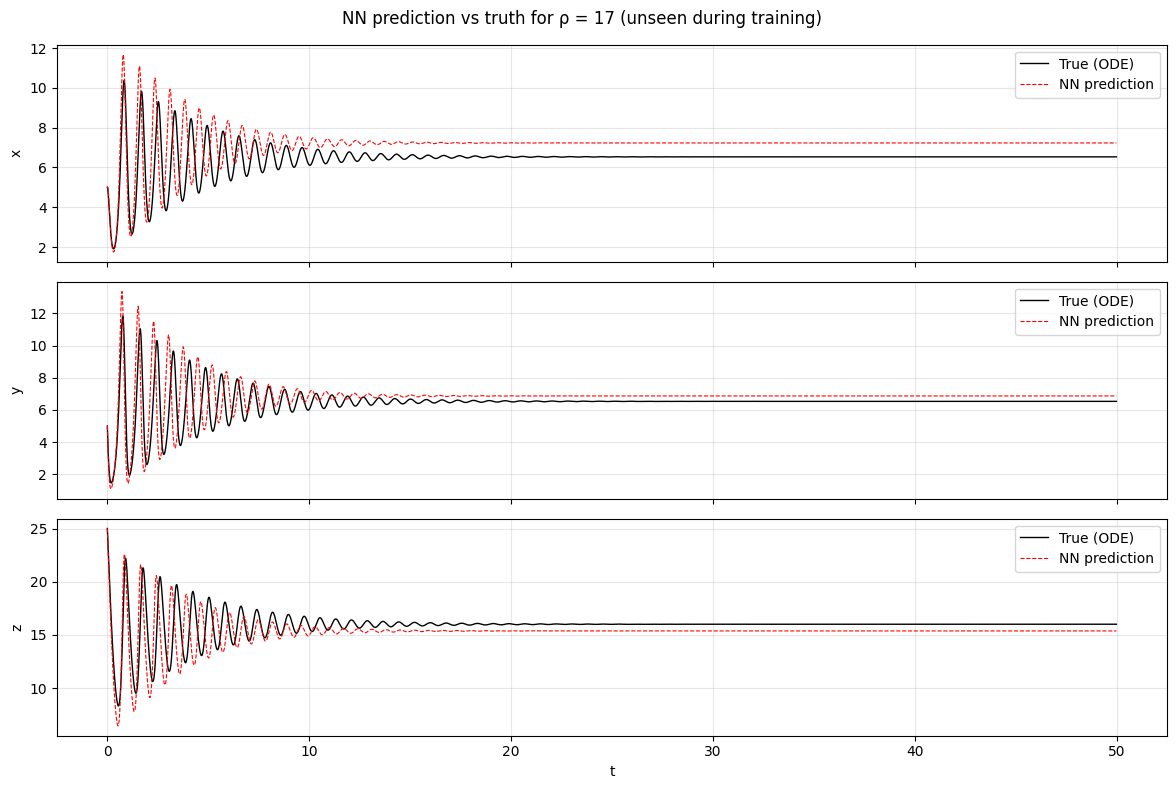

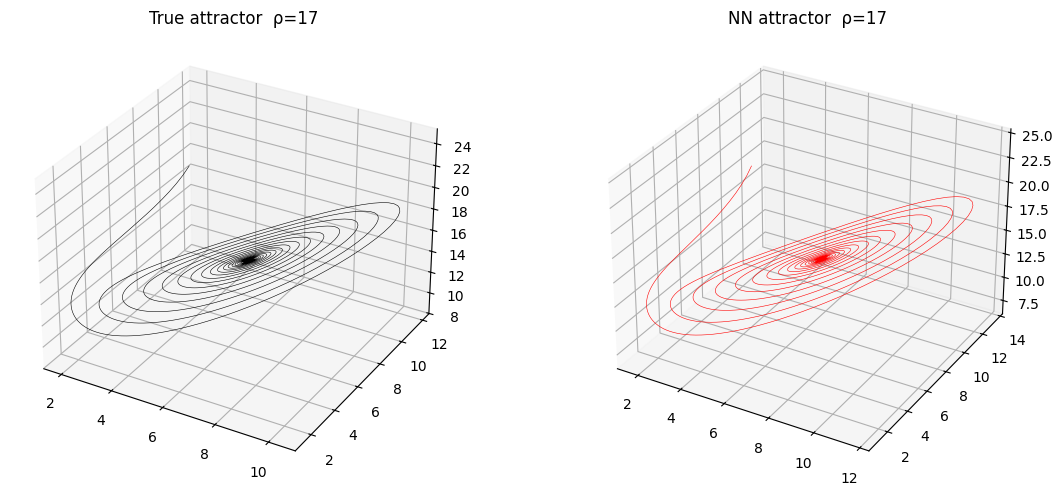

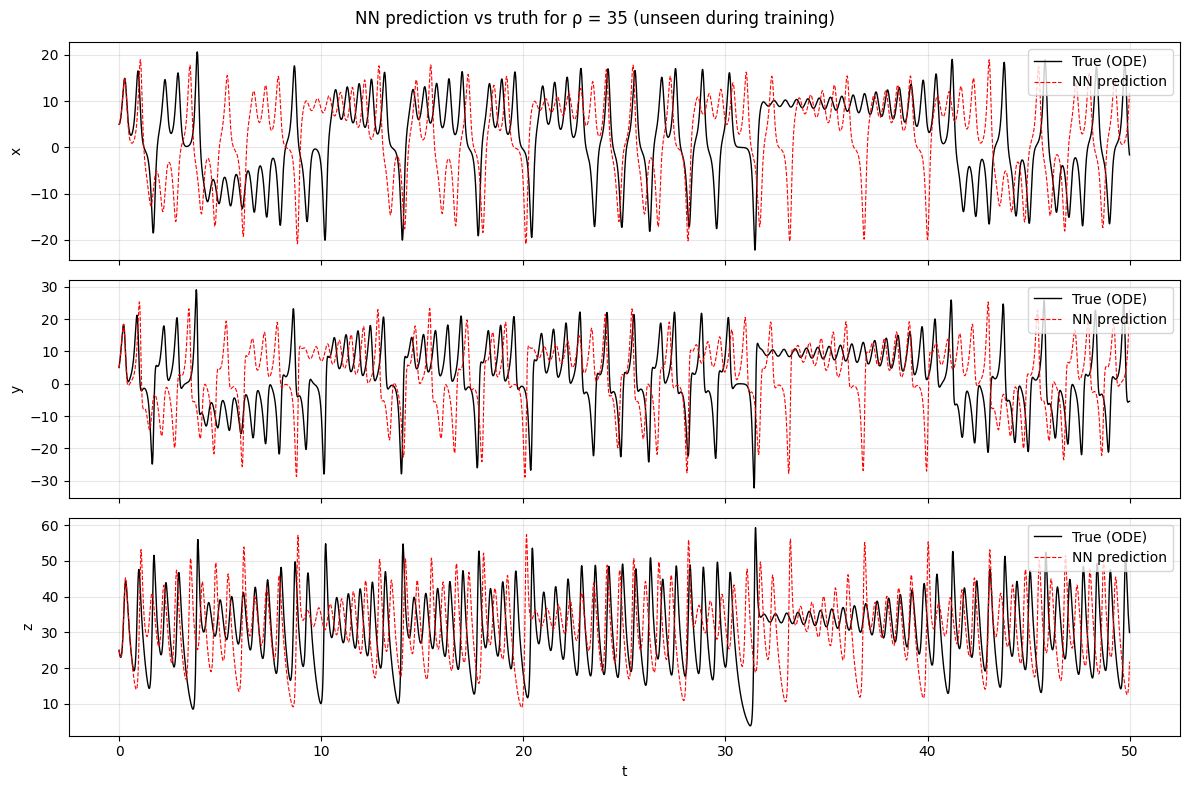

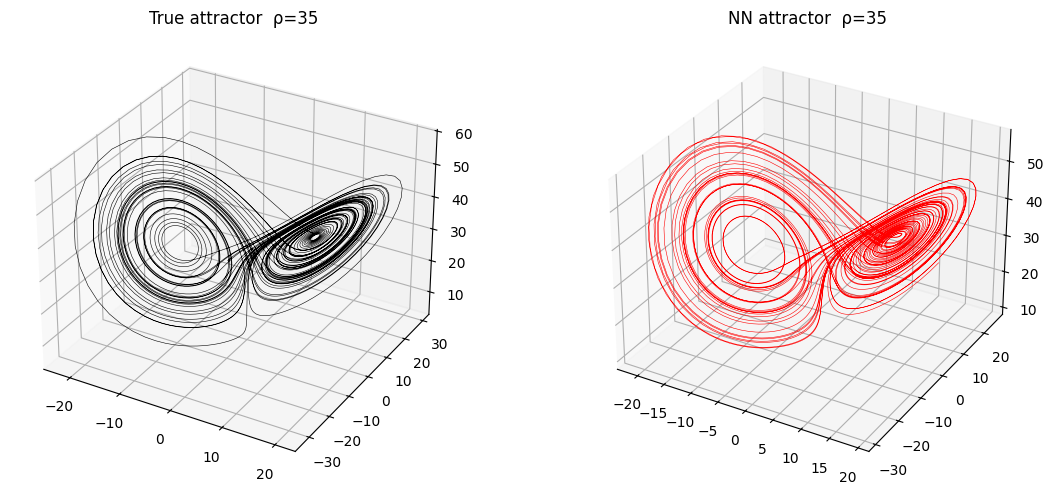

In [ ]:
# prediction rollout function
def rollout(model, x0, rho, n_steps, norm_X, norm_Y):
    """
    Normalized autoregressive rollout.
    
    Crucially:
      - normalize the input before feeding to the network
      - un-normalize the output to get real-space coordinates
      - that un-normalized output becomes the next raw state
    """
    model.eval()
    state = np.array(x0, dtype=np.float32)   # raw state (3,)
    trajectory = [state.copy()]

    with torch.no_grad():
        for _ in range(n_steps):
            # Build raw 4D input, normalize it
            raw_inp  = np.append(state, rho).astype(np.float32)        # (4,)
            norm_inp = ((raw_inp - norm_X.mean) / norm_X.std).astype(np.float32)

            inp_t    = torch.tensor(norm_inp).unsqueeze(0)              # (1, 4)
            norm_out = model(inp_t).squeeze(0).numpy()                  # (3,) normalized

            # Un-normalize output → back to real Lorenz coordinates
            state = norm_out * norm_Y.std + norm_Y.mean                 # (3,)
            trajectory.append(state.copy())

    return np.array(trajectory)   # (n_steps+1, 3)

# Test on rho = 17 and rho = 35
t_span    = np.arange(0, T, dt)
n_steps   = len(t_span) - 1   # 4999 steps to cover 0 < t < T
x0_test   = np.array([5.0, 5.0, 25.0])   # arbitrary initial condition

for rho_test in [17, 35]:
    # Ground truth from ODE solver
    truth = odeint(lorenz_deriv, x0_test, t_span,
                   args=(sigma, beta, rho_test),
                   rtol=1e-12, atol=1e-12)
    
    # NN rollout
    pred = rollout(model, x0_test, rho_test, n_steps, norm_X, norm_Y)
    
    # Plot x, y, z components over time
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    labels = ['x', 'y', 'z']
    for i, (ax, lbl) in enumerate(zip(axes, labels)):
        ax.plot(t_span, truth[:, i], 'k',  lw=1.0, label='True (ODE)')
        ax.plot(t_span, pred[:, i],  'r--', lw=0.8, label='NN prediction')
        ax.set_ylabel(lbl)
        ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('t')
    fig.suptitle(f'NN prediction vs truth for ρ = {rho_test} (unseen during training)')
    plt.tight_layout(); plt.show()
    
    # 3D attractor comparison
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot(*truth.T, lw=0.4, color='black')
    ax1.set_title(f'True attractor  ρ={rho_test}')
    
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot(*pred.T,  lw=0.4, color='red')
    ax2.set_title(f'NN attractor  ρ={rho_test}')
    plt.tight_layout(); plt.show()

## (b) Pick an arbitrary value for ρ. Train another neural network that advances the solution from t to t +∆t. In training your neural network, only include data up to an arbitrary pre-specified time T. Use your trained neural network to see how far in the future t > T you can predict (extrapolate). Deliverables: Similar to part a (convergence plots and your results).

# Important Notes:

## Important note 1: There are many arbitrary choices in this problem and also in designing the neural network, the architecture has many hyperparameters. Therefore, I anticipate the solutions to be very different between students and also the neural networks in the codes to be very different.

## Important note 2: It is ok to get a sample PyTorch neural network code online (or GPT) and then modify for the purpose of this assignment. Just make sure you study the code and make sure it makes sense and then play with the hyperparameters to come up with appropriate architecture, etc.

## Important note 3: If you like to study another dynamical system (systems of ODEs) other than Lorenz system that is fine but please explain the equation and discuss why you selected this system.